<a href="https://colab.research.google.com/github/Sehej15976/Applied-Data-Science/blob/main/FINAL_A21_ADS_EXP02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
#import the drive
from google.colab import drive


drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/ML/WA_Fn-UseC_-HR-Employee-Attrition.csv')
# Describe the numeric columns in the DataFrame
description = data.describe()

# Print the summary statistics
print(description)

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

In [ ]:
# Handle missing values: Fill numerical columns with the mean and categorical columns with the mode
for col in data.columns:
    if data[col].dtype == 'object':  # Categorical columns
        mode_value = data[col].mode()[0]
        data[col].fillna(mode_value, inplace=True)
    elif data[col].dtype in ['int64', 'float64']:  # Numerical columns
        mean_value = data[col].mean()
        data[col].fillna(mean_value, inplace=True)

# Encode categorical columns using LabelEncoder
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
categorical_columns = data.select_dtypes(include=['object']).columns

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Display the encoded dataset
print("Encoded dataset:\n", data.head())

Encoded dataset:
    Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EmployeeCount  EmployeeNumber  ...  \
0          2               1              1               1  ...   
1          1               1              1               2  ...   
2          2               4              1               4  ...   
3          4               1              1               5  ...   
4          1               3              1               7  ...   

   RelationshipSatisfaction  StandardHours  StockOptionLevel  \
0                         1             

<ipython-input-17-524af1008423>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(mean_value, inplace=True)
<ipython-input-17-524af1008423>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

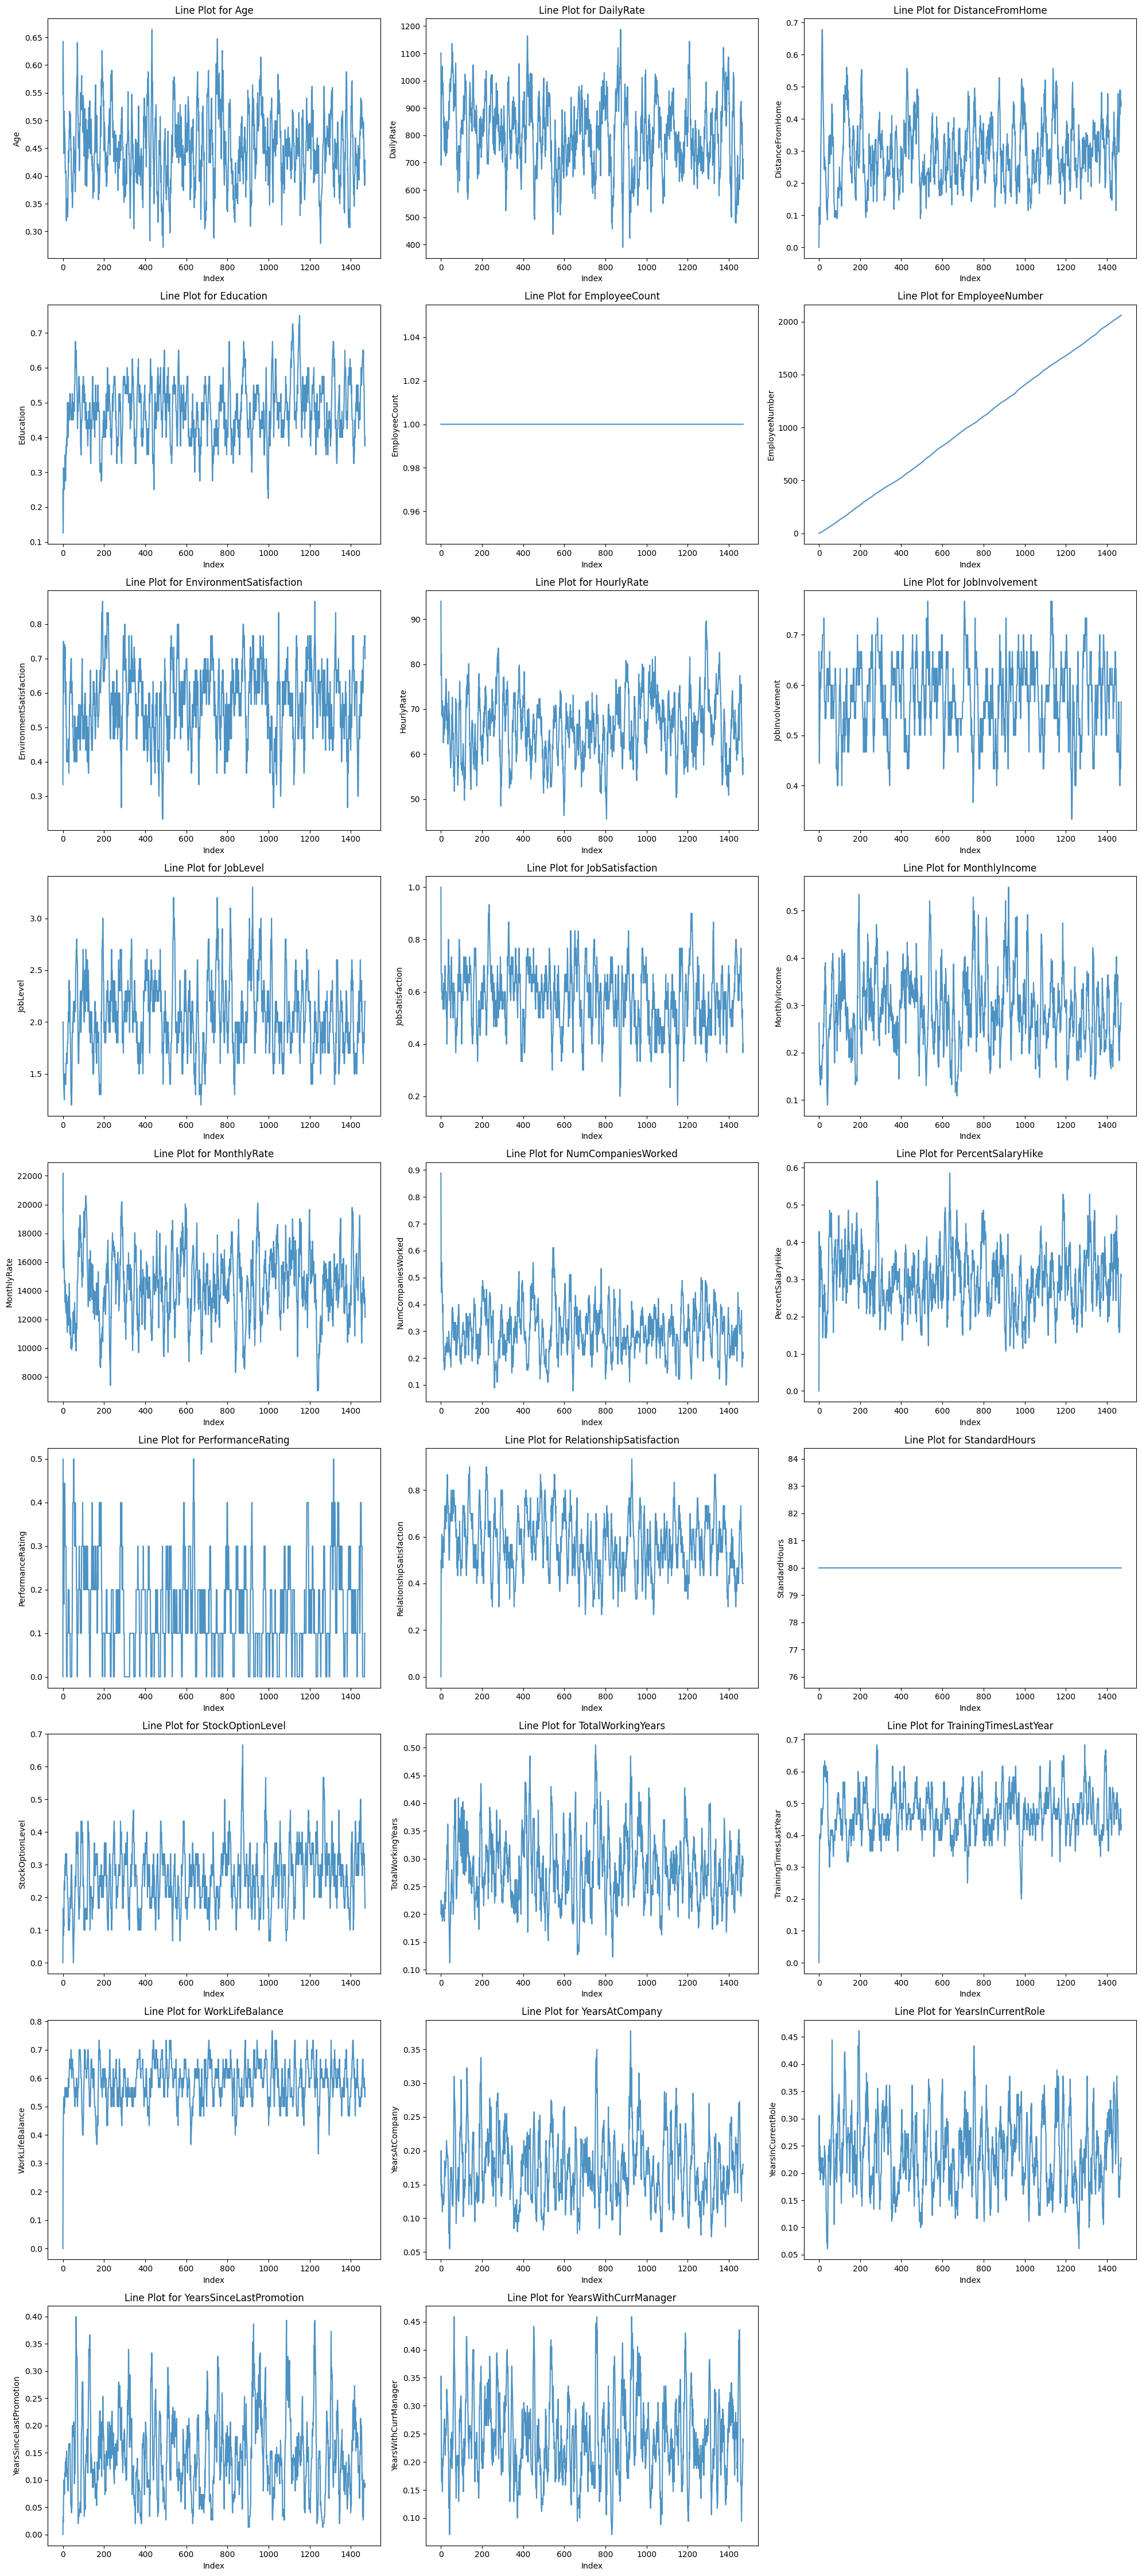

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import math

X = data.drop('Attrition', axis=1)
y = data['Attrition']

# Select only numerical columns for rolling mean calculation
numerical_columns = X.select_dtypes(include=['number']).columns
# Define the number of columns and rows for subplots
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, column in enumerate(numerical_columns): # Iterate through numerical columns only
    sorted_data = X[column].sort_index()  # Sort index for a smoother plot
    smoothed_data = sorted_data.rolling(window=10, min_periods=1).mean()  # Apply rolling mean

    axes[i].plot(sorted_data.index, smoothed_data, linestyle='-', marker='', alpha=0.8)
    axes[i].set_title(f'Line Plot for {column}')
    axes[i].set_xlabel('Index')
    axes[i].set_ylabel(column)

# Remove extra subplots
for i in range(len(numerical_columns), len(axes)): # Adjust range for numerical columns
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

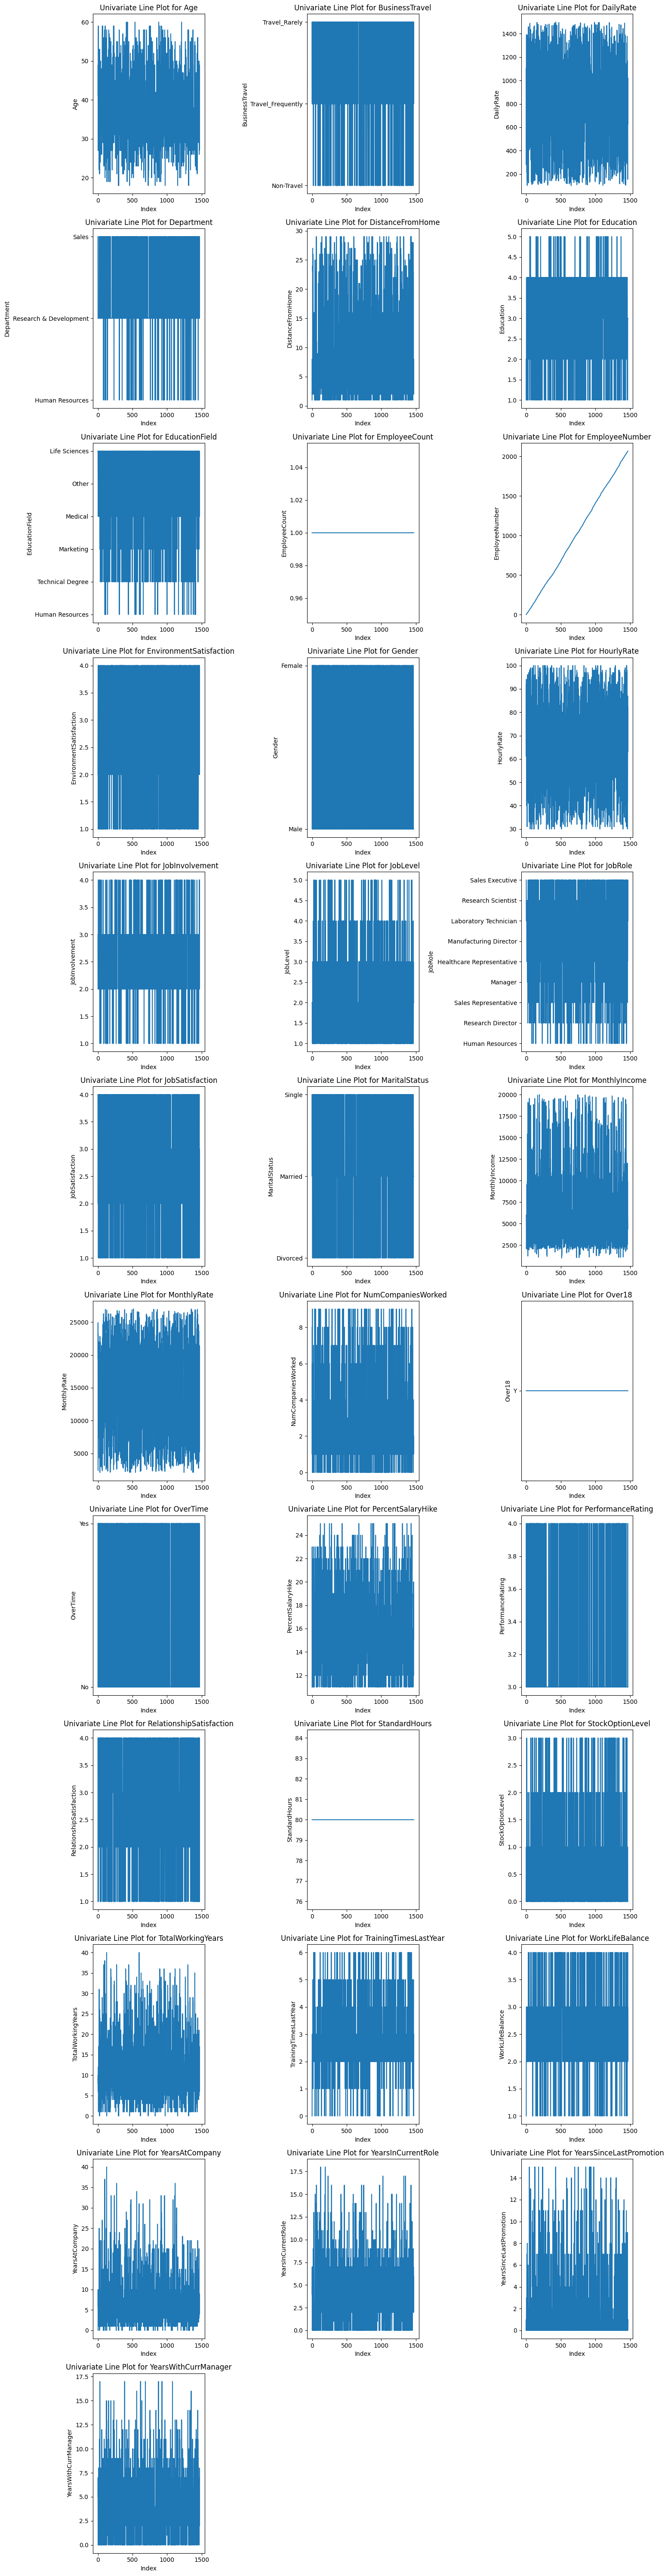

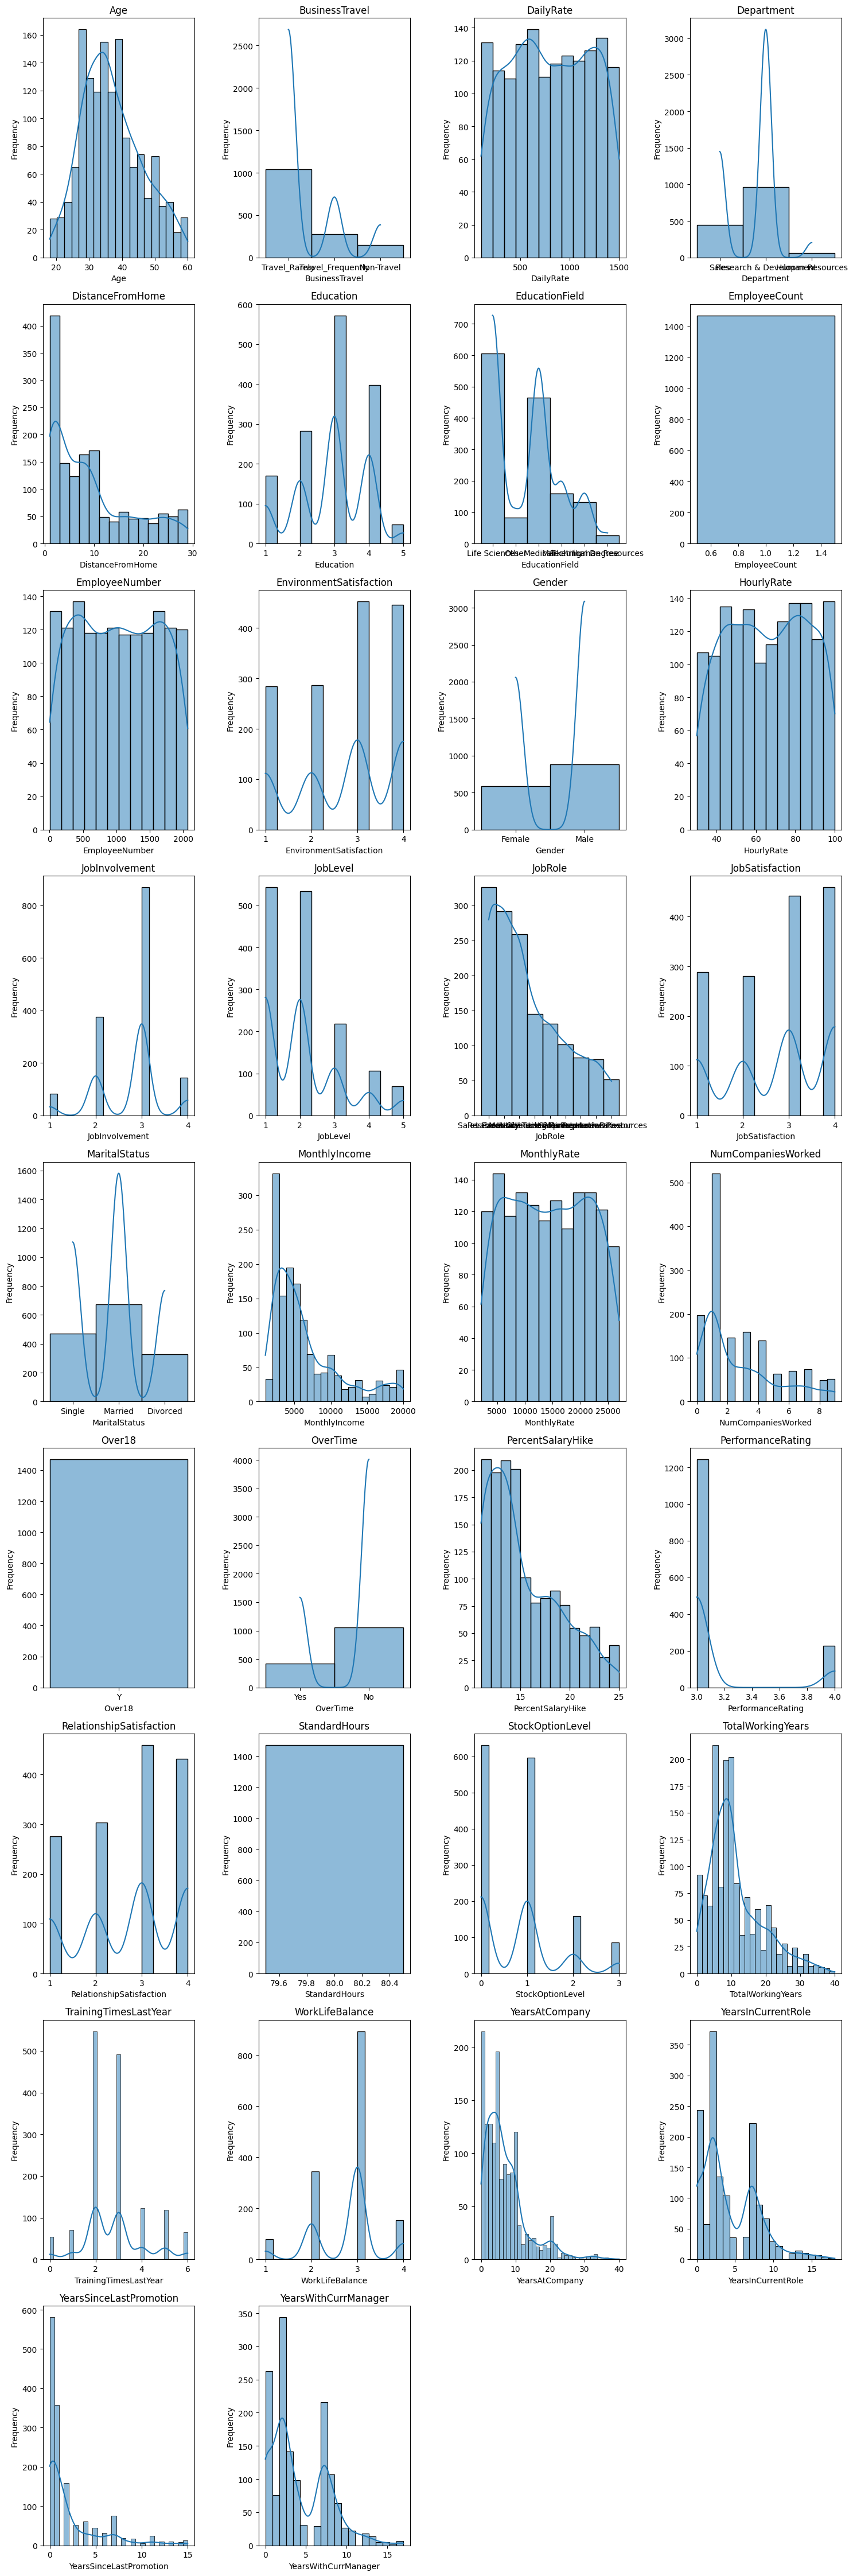

In [ ]:
import math
# Feature and target definition
# Assuming 'diagnosis' is the target column (adjust if different)
X = data.drop(['Attrition'], axis=1)  # Replace 'diagnosis' with your target column
y = data['Attrition']

# Univariate line plots for all features
n_cols = 3
n_rows = math.ceil(len(X.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, column in enumerate(X.columns):
    sns.lineplot(x=X.index, y=X[column], ax=axes[i])
    axes[i].set_title(f'Univariate Line Plot for {column}')
    axes[i].set_xlabel('Index')
    axes[i].set_ylabel(column)

for i in range(len(X.columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# # Pairwise scatter plots for selected feature pairs
# column_pairs = [(X.columns[i], X.columns[i + 1]) for i in range(len(X.columns) - 1)]
# n_cols = 3
# n_rows = math.ceil(len(column_pairs) / n_cols)

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
# axes = axes.flatten()

# for i, (col1, col2) in enumerate(column_pairs):
#     sns.scatterplot(x=data[col1], y=data[col2], ax=axes[i])
#     axes[i].set_title(f'{col1} vs {col2}')
#     axes[i].set_xlabel(col1)
#     axes[i].set_ylabel(col2)

# for j in range(i + 1, len(axes)):
#     axes[j].axis('off')

# plt.tight_layout()
# plt.show()

# Univariate histograms
n_cols = 4
n_rows = math.ceil(len(X.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, column in enumerate(X.columns):
    sns.histplot(X[column], kde=True, ax=axes[i])
    axes[i].set_title(f'{column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()



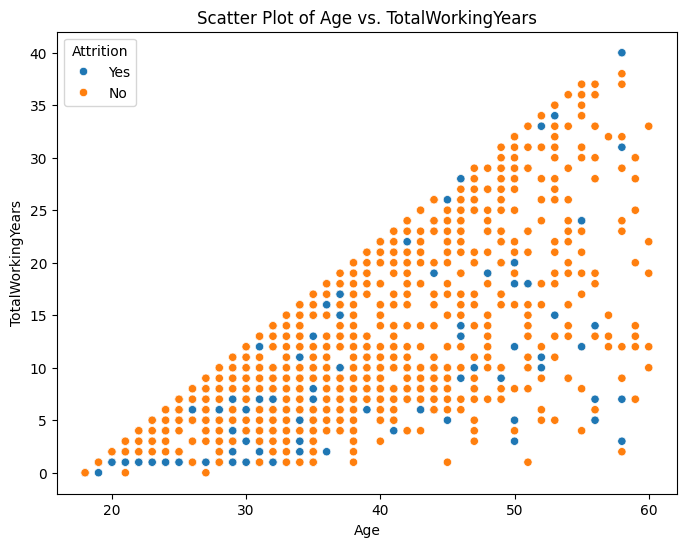

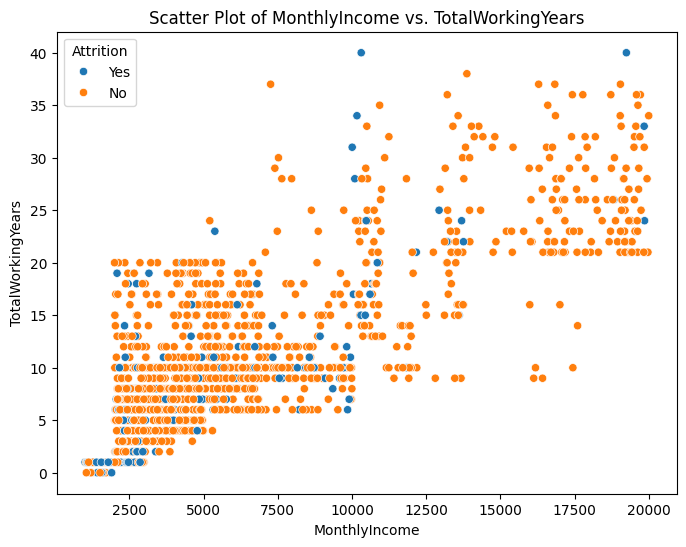

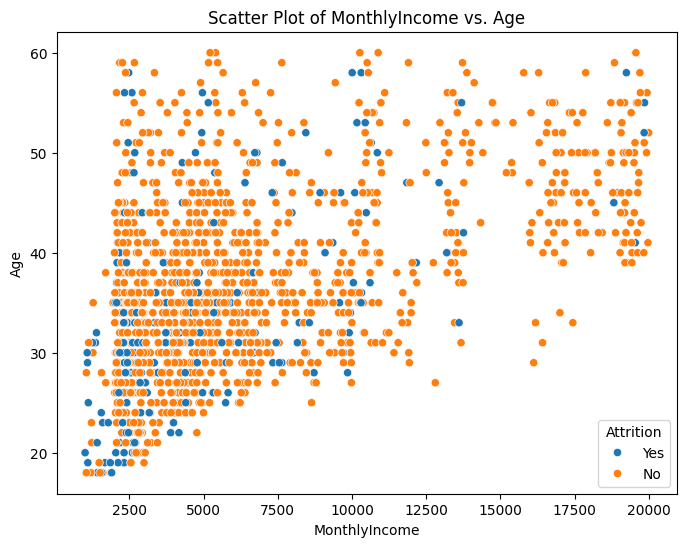

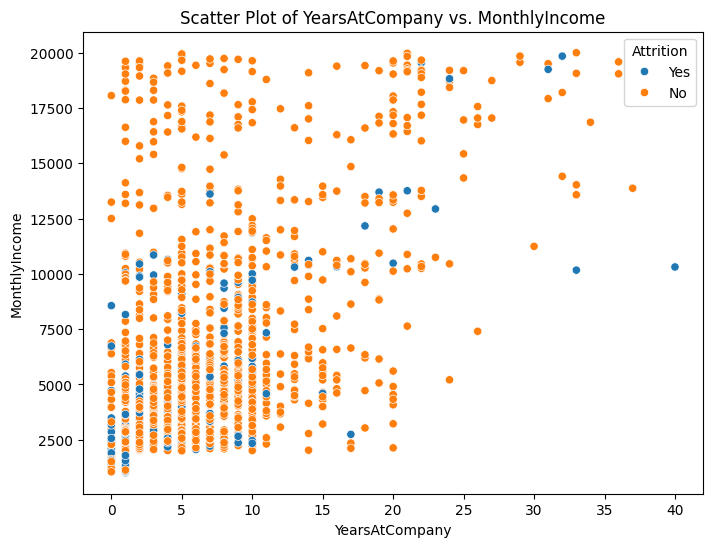

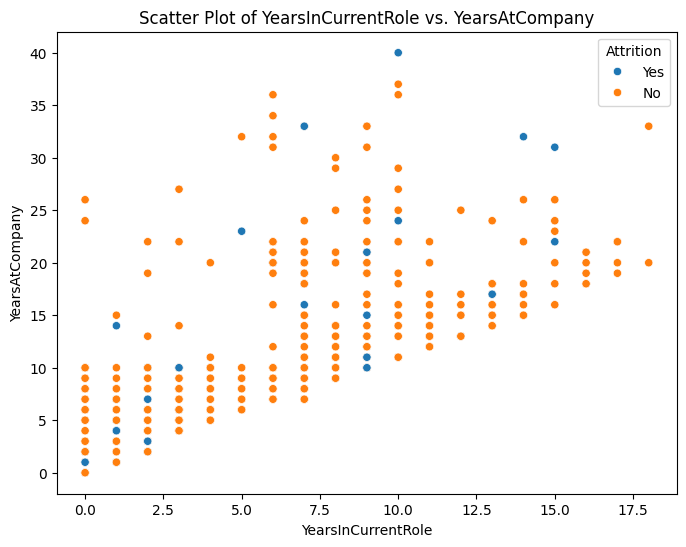

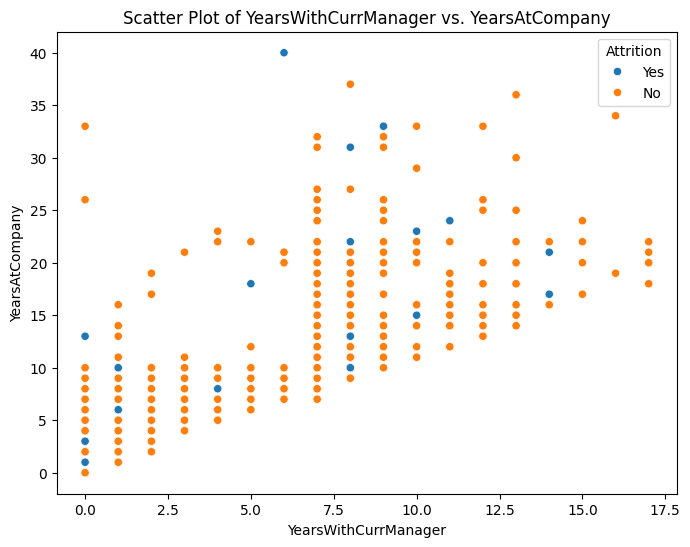

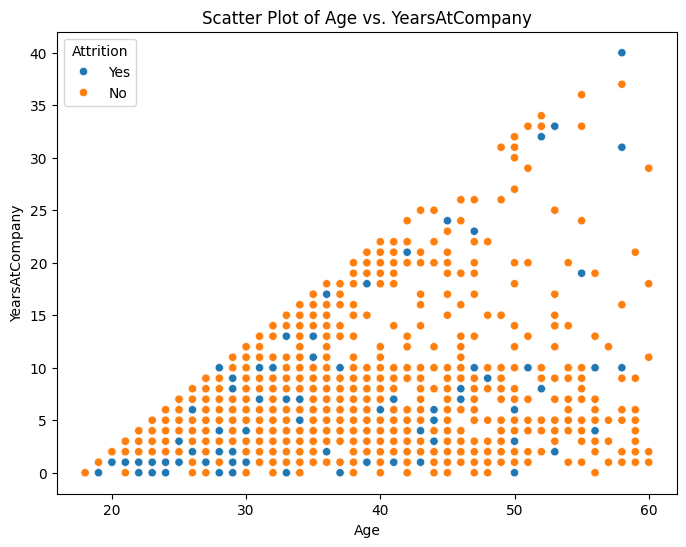

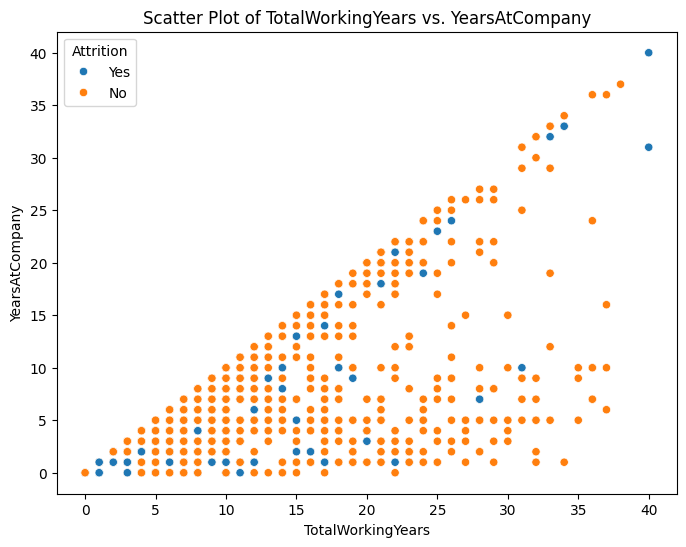

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataset is loaded into a pandas DataFrame called 'data'

# Define column pairs for scatter plots
column_pairs = [
    ('Age', 'TotalWorkingYears'),  # Moderately strong positive linear relationship
    ('MonthlyIncome', 'TotalWorkingYears'),  # Strongest positive linear relationship
    ('MonthlyIncome','Age'),

    ('YearsAtCompany', 'MonthlyIncome'),  # Longer tenure might lead to higher income
    ('YearsInCurrentRole', 'YearsAtCompany'),  # More years in the current role, more years at the company
    ('YearsWithCurrManager', 'YearsAtCompany'),  # Longer with the same manager, longer at the company

    ('Age','YearsAtCompany'),
    ('TotalWorkingYears', 'YearsAtCompany'),

    # ('DistanceFromHome', 'JobSatisfaction'),  # Longer distance might decrease satisfaction
    # ('DistanceFromHome', 'EnvironmentSatisfaction'), # Longer distance might decrease satisfaction
    # ('YearsSinceLastPromotion', 'JobSatisfaction'),  # Lack of promotion might decrease satisfaction
    # ('YearsSinceLastPromotion', 'EnvironmentSatisfaction'),  # Lack of promotion might decrease satisfaction
    # ('NumCompaniesWorked', 'YearsAtCompany'), # More companies worked at could mean shorter tenure at current company
    # ('NumCompaniesWorked', 'YearsInCurrentRole') # More companies worked at could mean shorter tenure in current role

]

# Create scatter plots for each pair
for x_col, y_col in column_pairs:
    plt.figure(figsize=(8, 6))  # Adjust figure size as needed
    sns.scatterplot(x=x_col, y=y_col, data=data, hue='Attrition')  # Color-code by 'Attrition'
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'Scatter Plot of {x_col} vs. {y_col}')
    plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Assuming your dataset is loaded into a pandas DataFrame called 'data'

# plt.figure(figsize=(10, 6))  # Adjust figure size as needed
# sns.scatterplot(x='Age', y='MonthlyIncome', data=data, hue='Attrition')
# plt.xlabel('Age')
# plt.ylabel('Monthly Income')
# plt.title('Scatter Plot of Monthly Income vs. Age')
# plt.show()

**We can see that as the age of the person increases, monthly income increases. We can also see a high rate of attrition among the employees with low monthly incomes.**

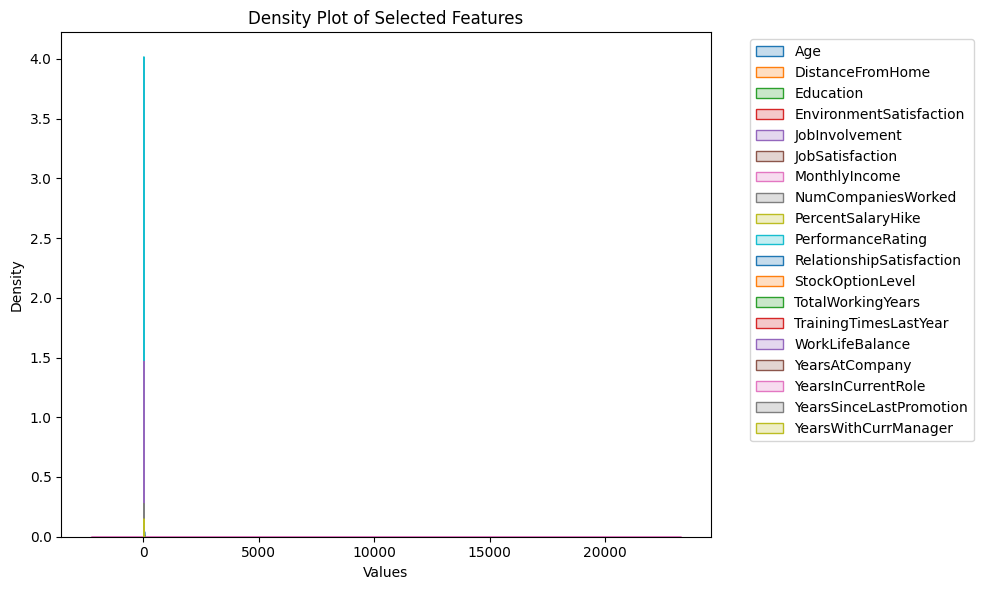

In [ ]:


# Assuming your dataset is loaded into the 'data' DataFrame

# Specify the columns you want to include in the density plot.
# Make sure these columns exist in your dataset and are numerical.
cols_for_density = ['Age', 'DistanceFromHome', 'Education',
                    'EnvironmentSatisfaction', 'JobInvolvement',
                    'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked',
                    'PercentSalaryHike', 'PerformanceRating',
                    'RelationshipSatisfaction', 'StockOptionLevel',
                    'TotalWorkingYears', 'TrainingTimesLastYear',
                    'WorkLifeBalance', 'YearsAtCompany',
                    'YearsInCurrentRole', 'YearsSinceLastPromotion',
                    'YearsWithCurrManager']

# Create the density plot
plt.figure(figsize=(10,6))
for col in cols_for_density:
    if data[col].dtype in ['int64', 'float64']:  # Check if column is numerical
        sns.kdeplot(data=data, x=col, label=col, fill=True)
    else:
        print(f"Skipping column '{col}' as it is not numerical.")  # Print a message for skipped columns

plt.title("Density Plot of Selected Features")
plt.xlabel("Values")
plt.ylabel("Density")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Place legend outside the plot for better readability
plt.tight_layout()
plt.show()

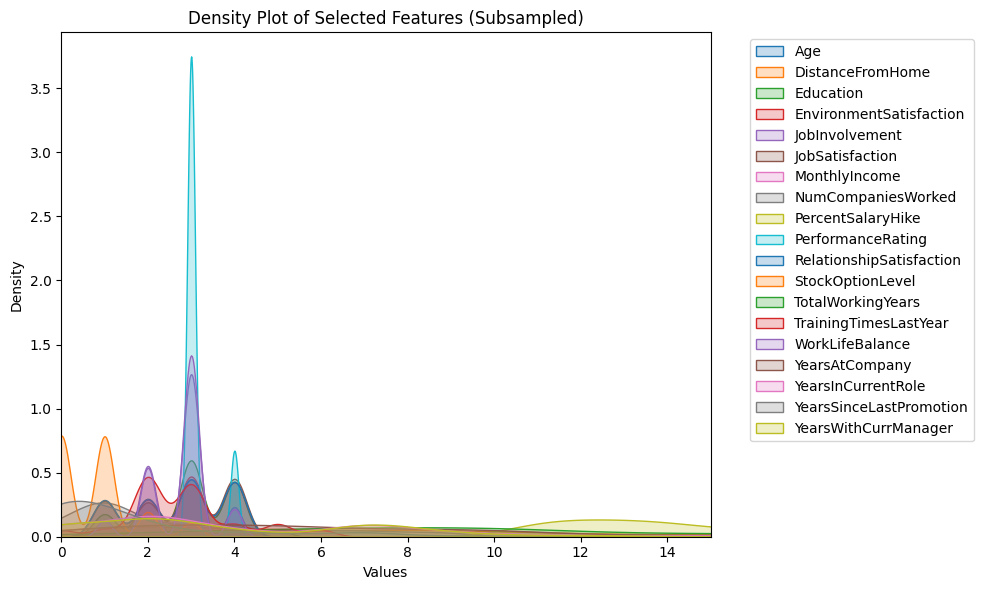

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import random  # Import the random module

cols_for_density = ['Age', 'DistanceFromHome', 'Education',
                    'EnvironmentSatisfaction', 'JobInvolvement',
                    'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked',
                    'PercentSalaryHike', 'PerformanceRating',
                    'RelationshipSatisfaction', 'StockOptionLevel',
                    'TotalWorkingYears', 'TrainingTimesLastYear',
                    'WorkLifeBalance', 'YearsAtCompany',
                    'YearsInCurrentRole', 'YearsSinceLastPromotion',
                    'YearsWithCurrManager']

# Set the number of data points to sample
sample_size = 1000

plt.figure(figsize=(10, 6))

for col in cols_for_density:
    if data[col].dtype in ['int64', 'float64']:
        # Randomly select data points for the density plot
        # Instead of creating a separate list, sample from the DataFrame
        data_sample = data.sample(n=sample_size)
        sns.kdeplot(data=data_sample, x=col, label=col, fill=True)
    else:
        print(f"Skipping column '{col}' as it is not numerical.")

# Set x-axis limits (adjust these values as needed)
plt.xlim(0,15)  # Example: Limit x-axis to 0-2000

plt.title("Density Plot of Selected Features (Subsampled)")
plt.xlabel("Values")
plt.ylabel("Density")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<ipython-input-38-fcfcd7dcd1c6>:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(data.index[i], data['Age'][i], s=data['Age'][i] * 1000,  # Scale bubble size


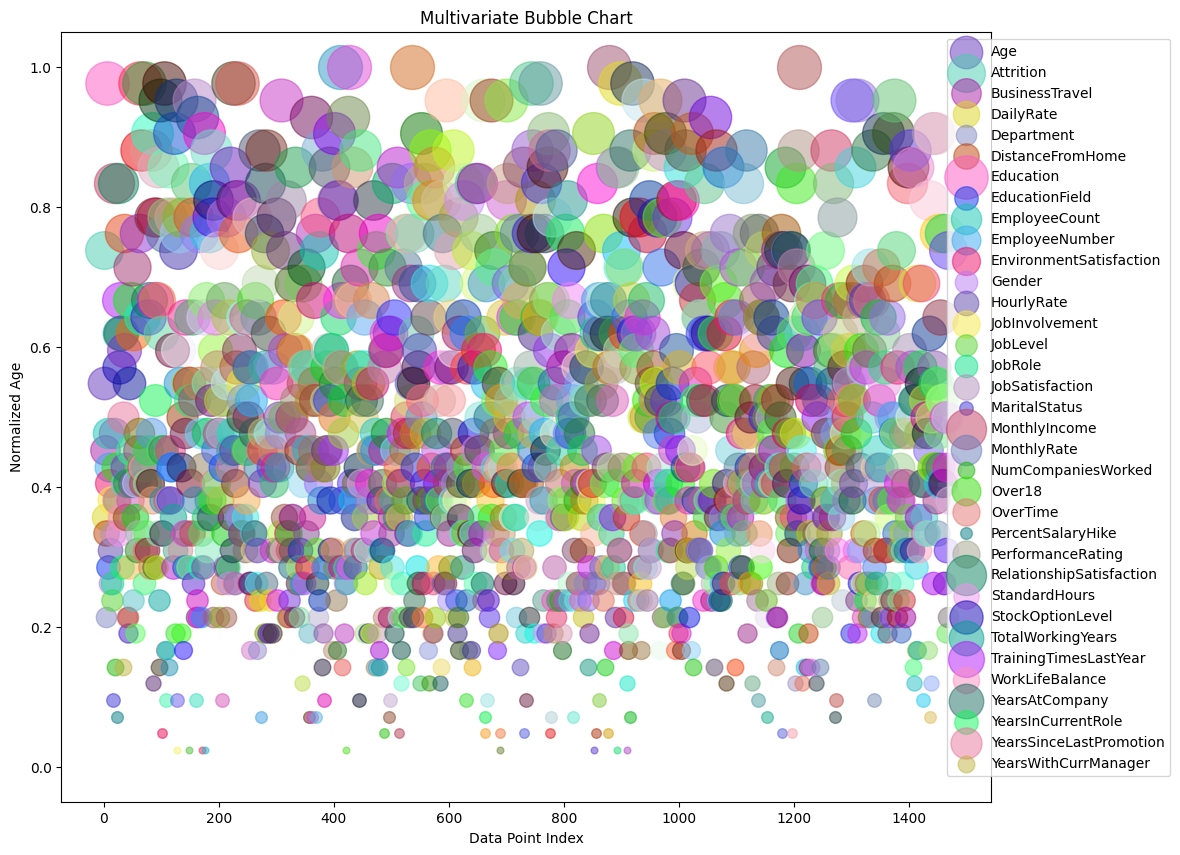

In [ ]:
numerical_cols = ['Age', 'DistanceFromHome', 'Education',
                  'EnvironmentSatisfaction', 'JobInvolvement',
                  'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked',
                  'PercentSalaryHike', 'PerformanceRating',
                  'RelationshipSatisfaction', 'StockOptionLevel',
                  'TotalWorkingYears', 'TrainingTimesLastYear',
                  'WorkLifeBalance', 'YearsAtCompany',
                  'YearsInCurrentRole', 'YearsSinceLastPromotion',
                  'YearsWithCurrManager']

for col in numerical_cols:
    data[col] = (data[col] - data[col].min()) / (data[col].max() - data[col].min())

plt.figure(figsize=(12, 10))

# Scatter plot with bubble size representing 'Age'
for i in range(len(data)):
    plt.scatter(data.index[i], data['Age'][i], s=data['Age'][i] * 1000,  # Scale bubble size
                c=np.random.rand(3,), alpha=0.5,
                label=data.columns[i] if i < len(data.columns) else "")  # Unique colors

plt.title('Multivariate Bubble Chart')
plt.xlabel('Data Point Index')
plt.ylabel('Normalized Age')  # Y-axis label

# Adjust legend to avoid overlap (optional)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

plt.show()

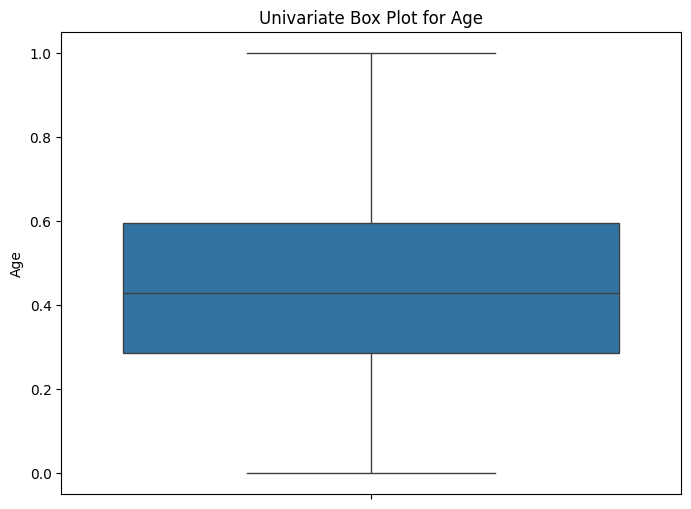

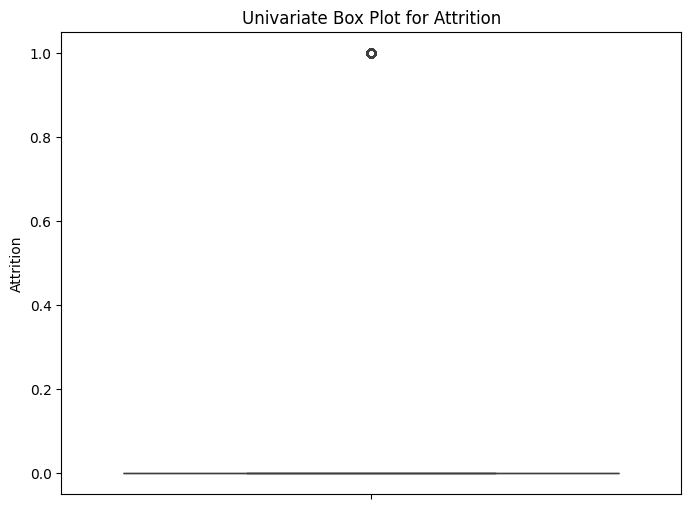

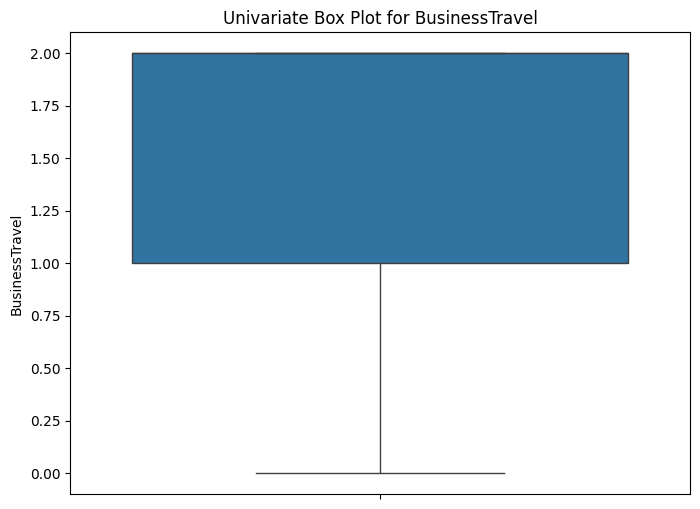

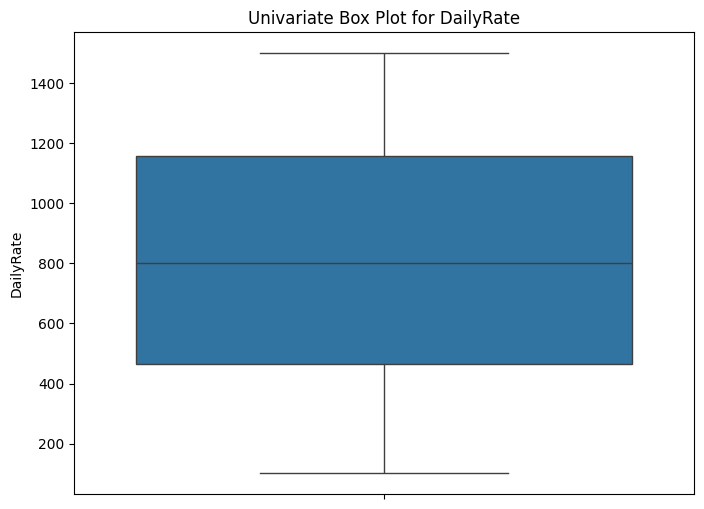

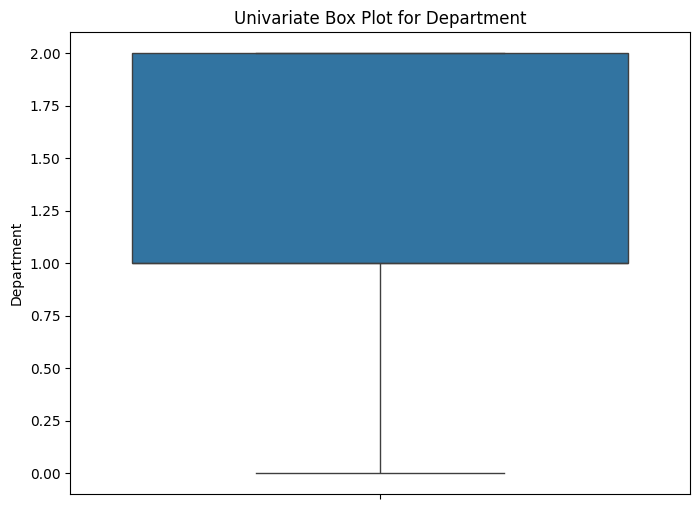

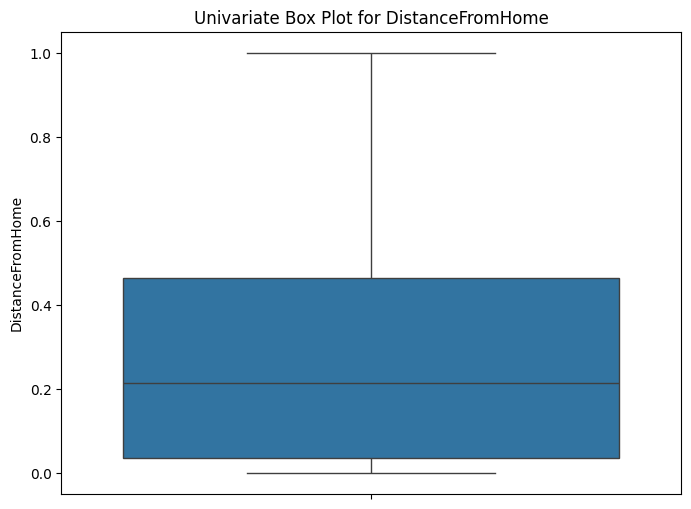

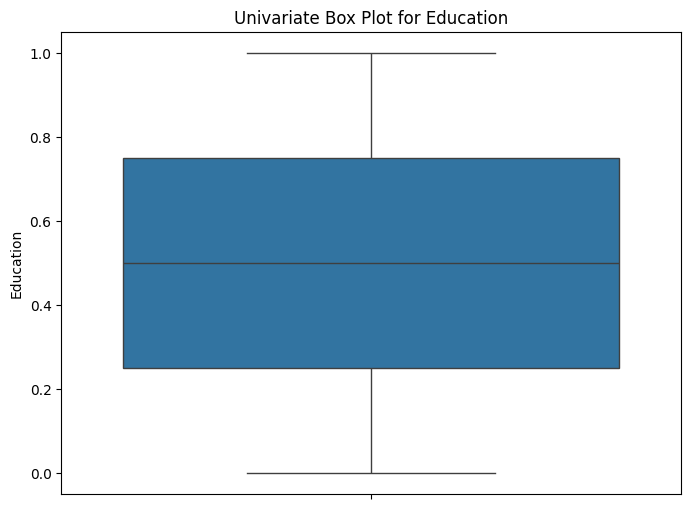

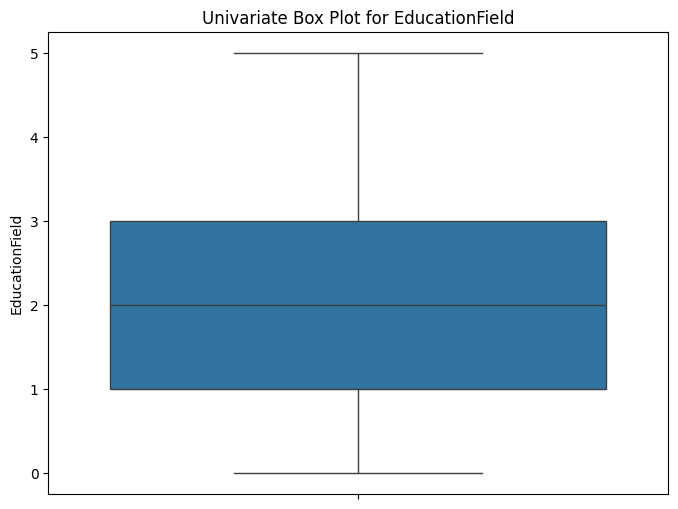

Skipping box plot for 'EmployeeCount' as it has only one unique value.


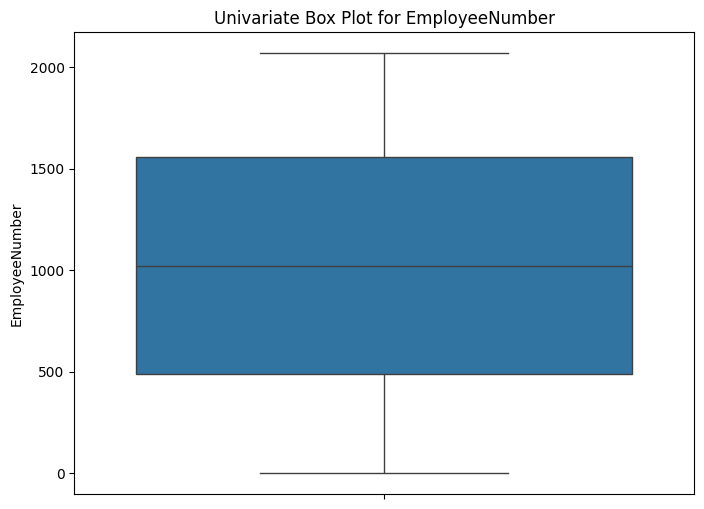

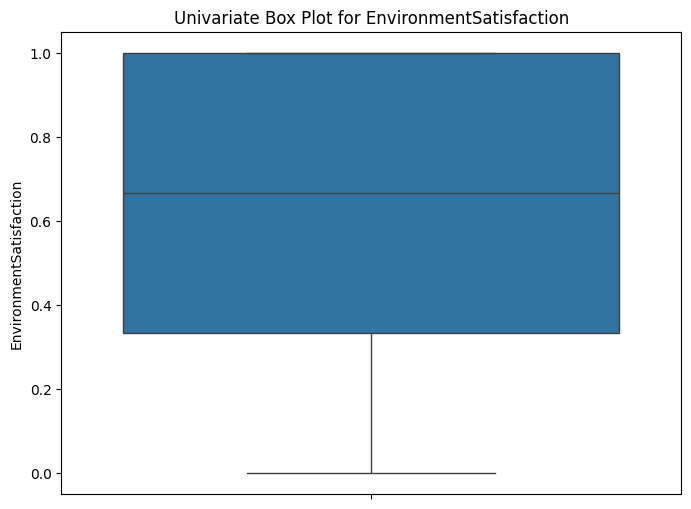

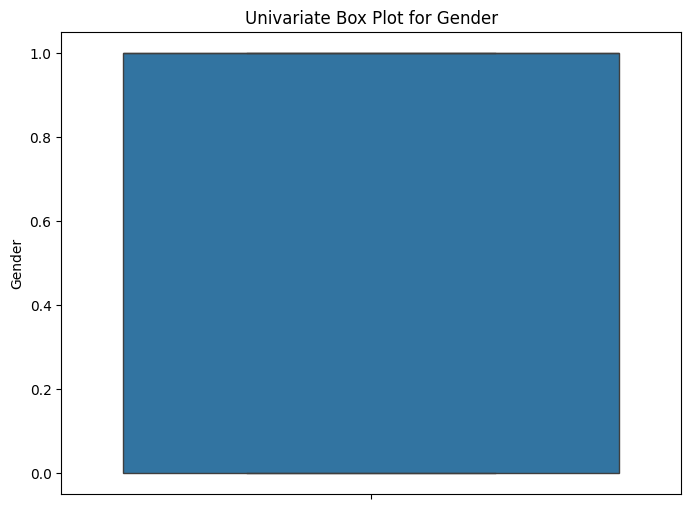

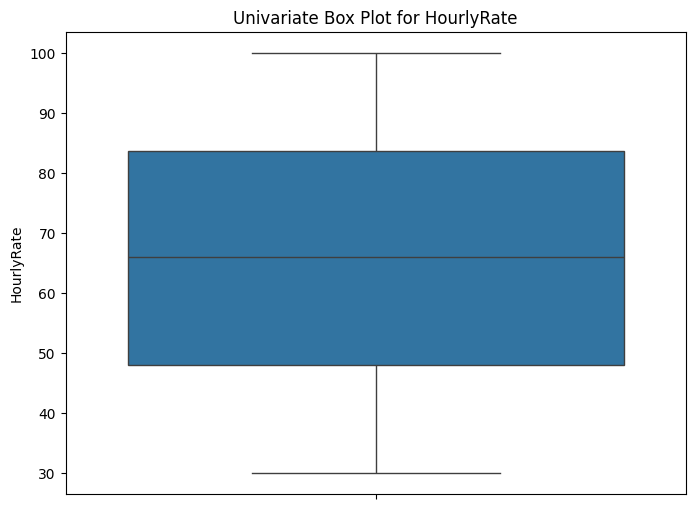

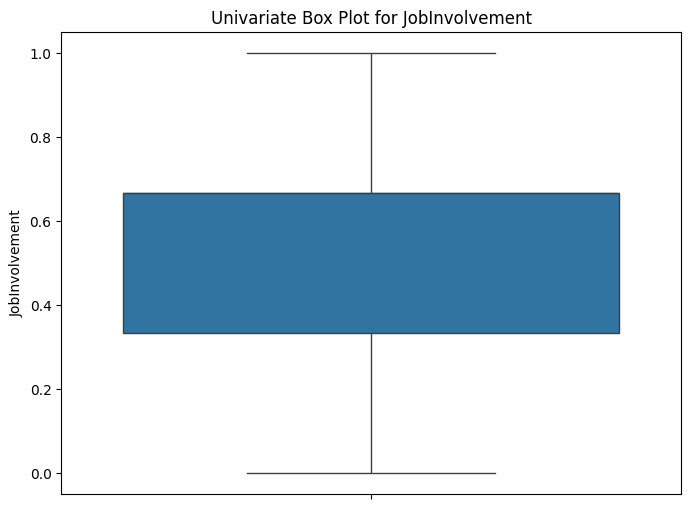

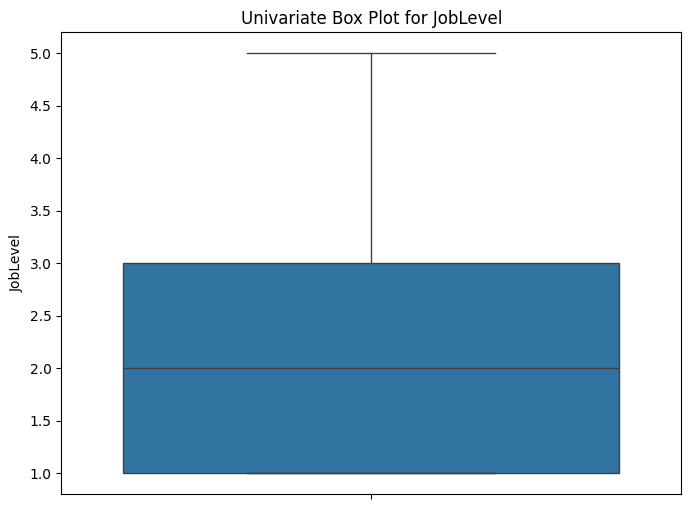

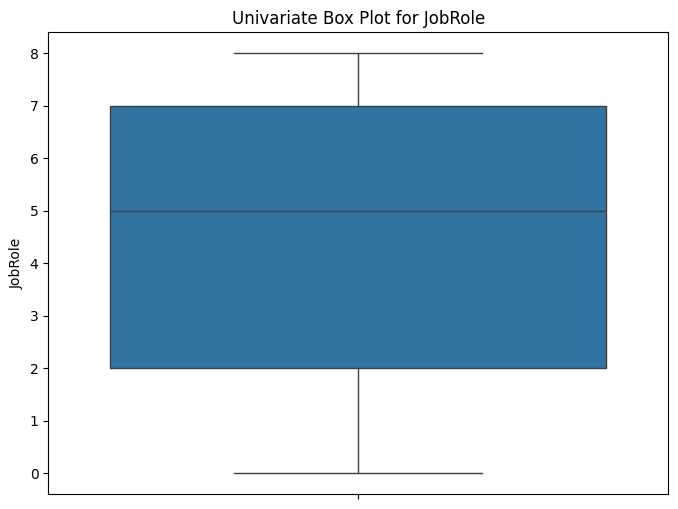

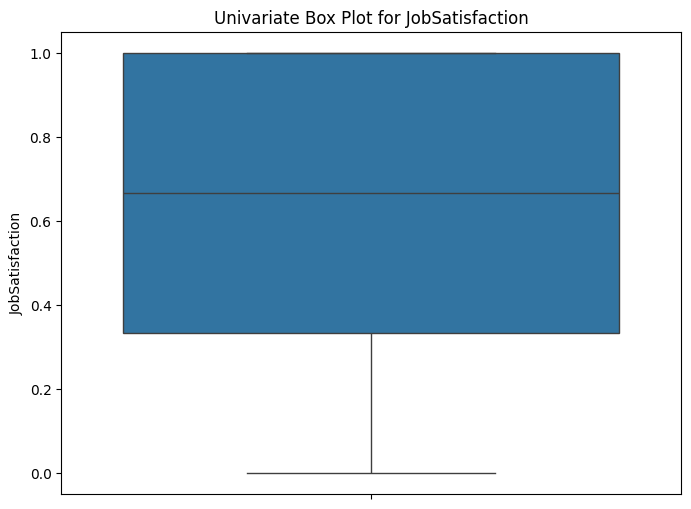

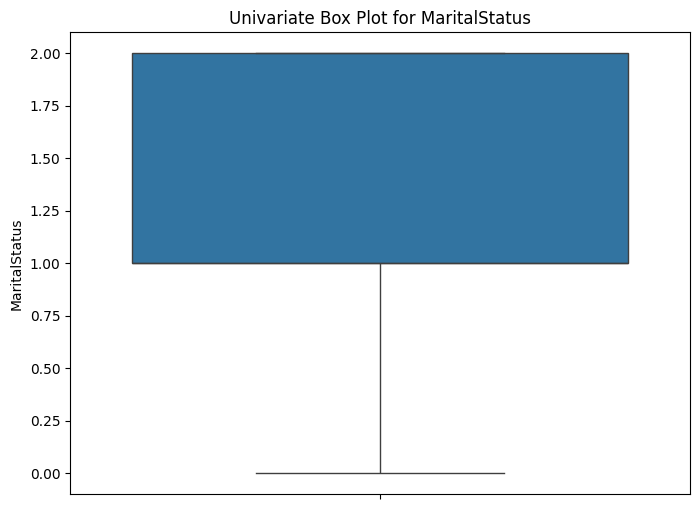

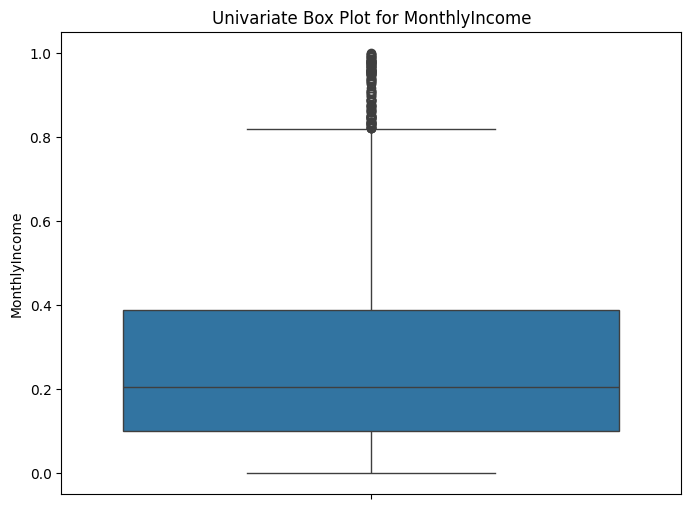

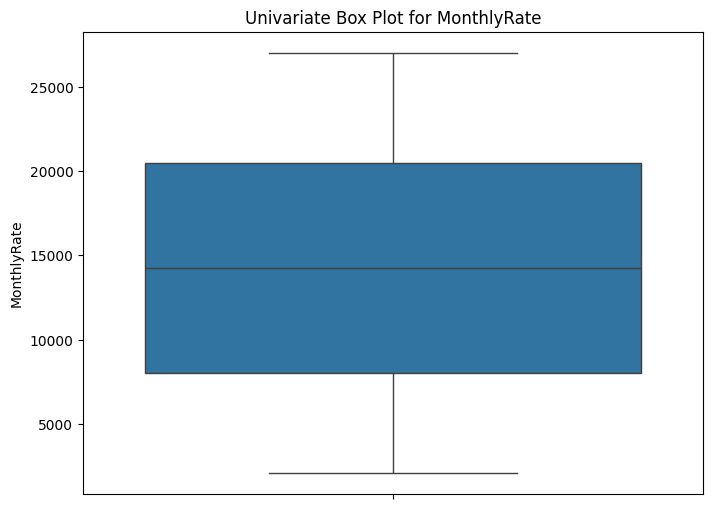

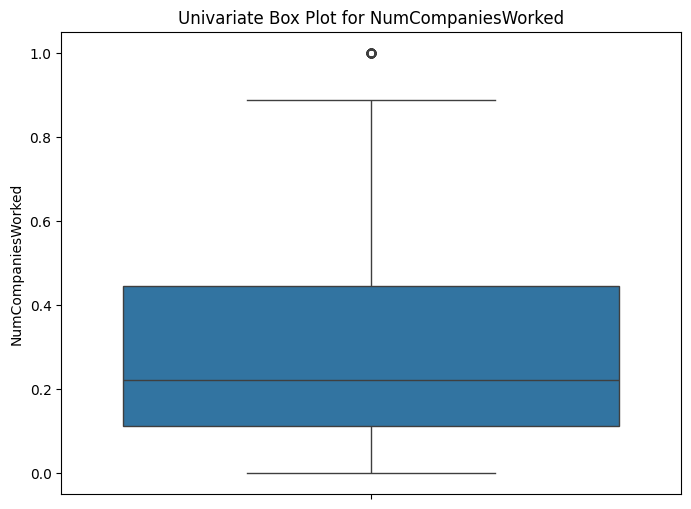

Skipping box plot for 'Over18' as it has only one unique value.


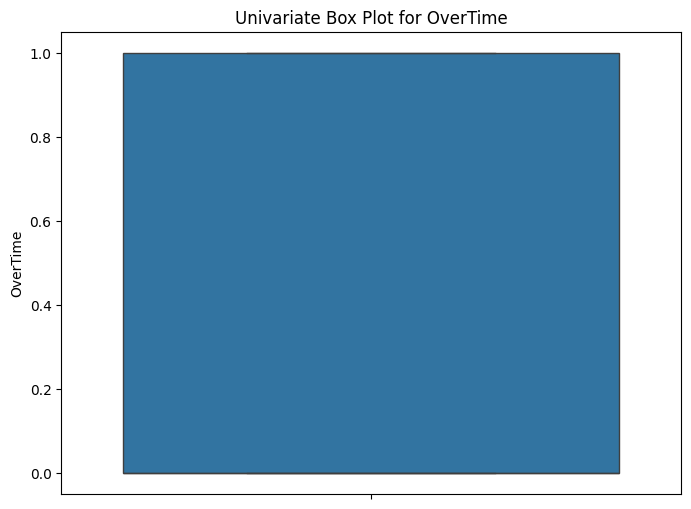

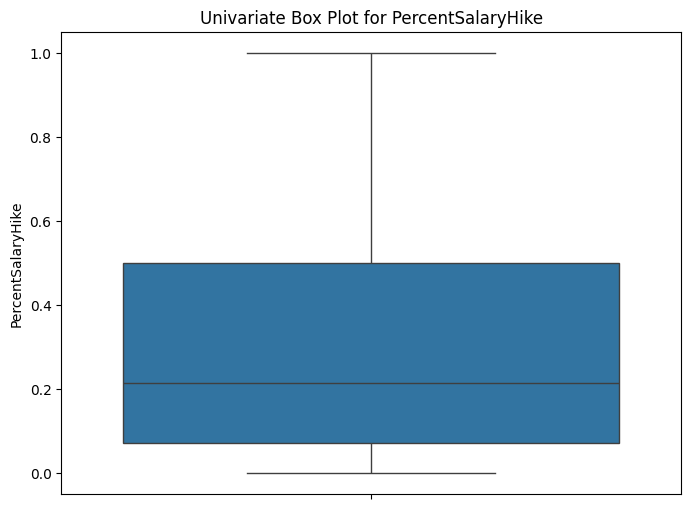

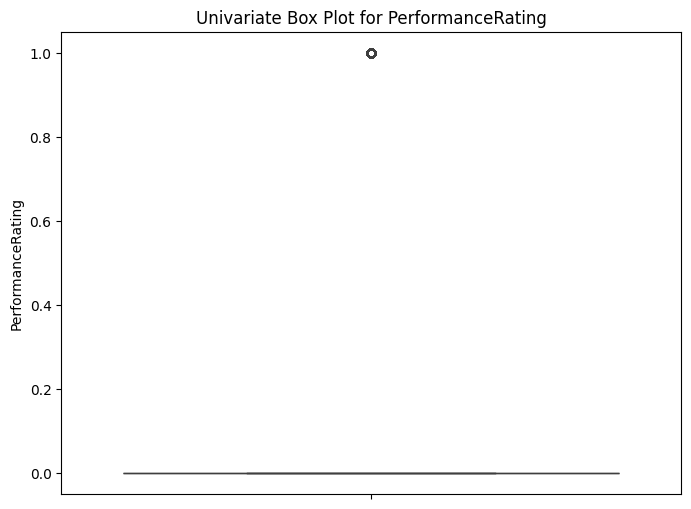

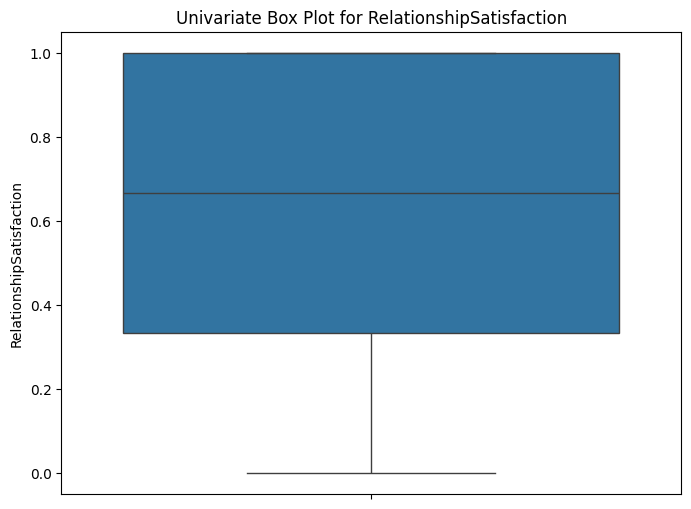

Skipping box plot for 'StandardHours' as it has only one unique value.


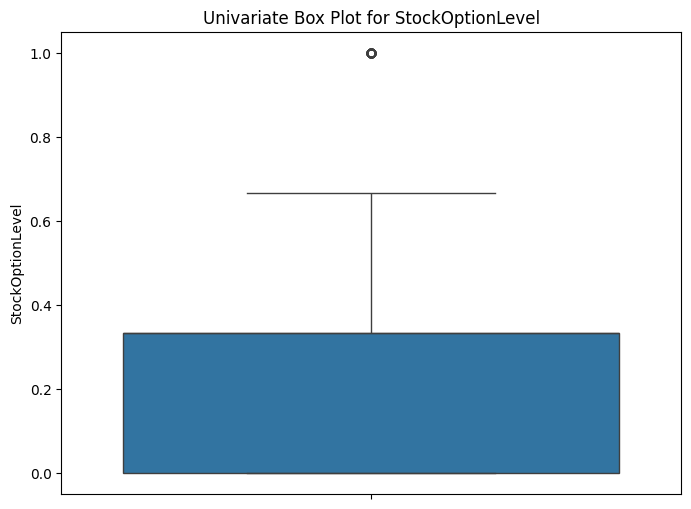

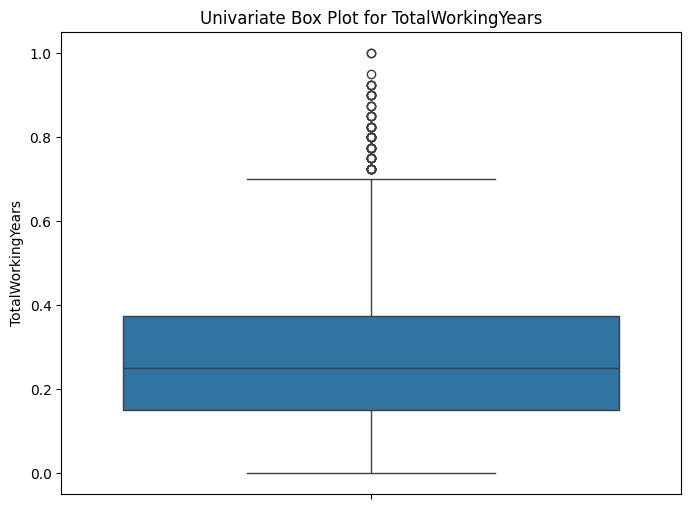

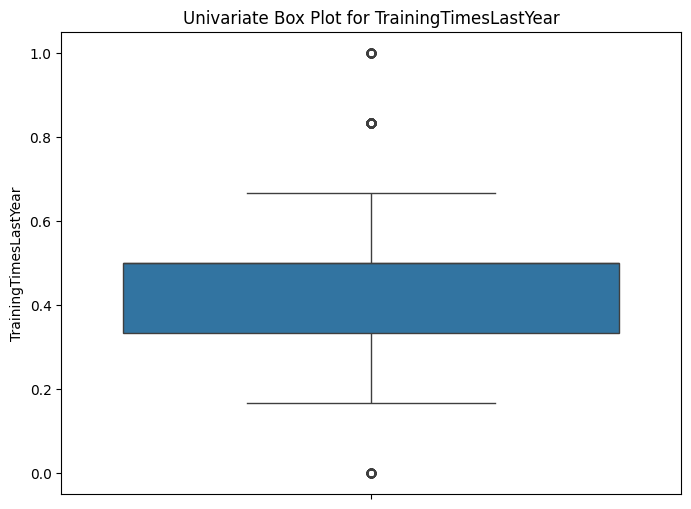

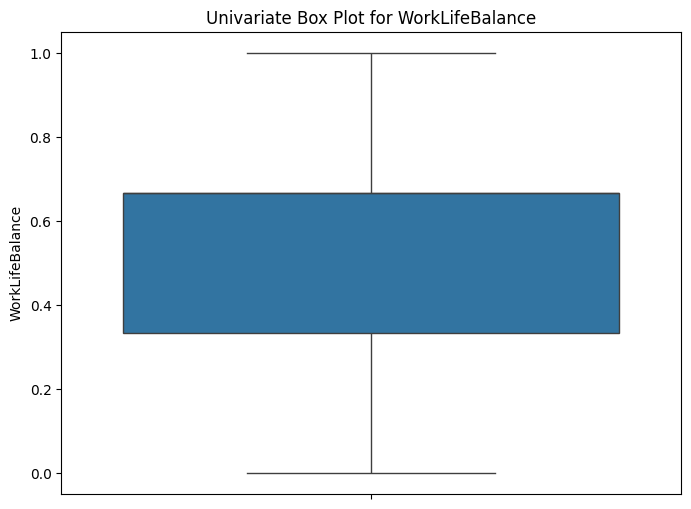

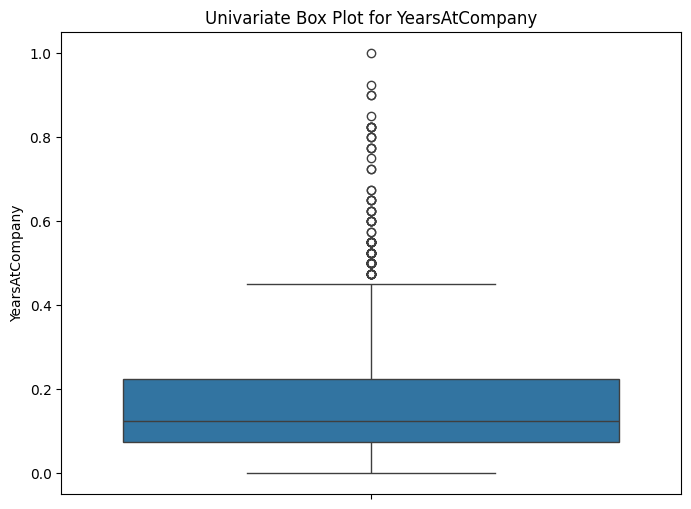

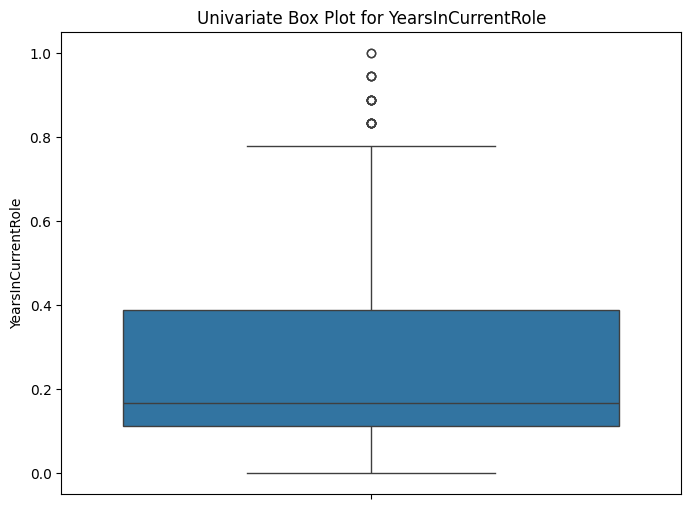

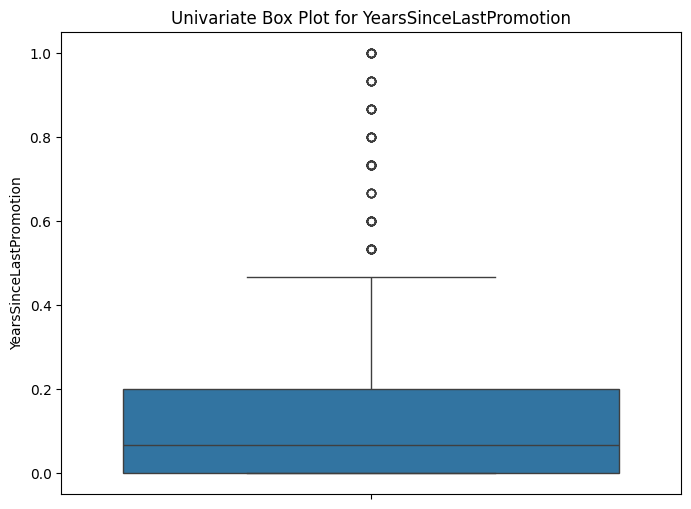

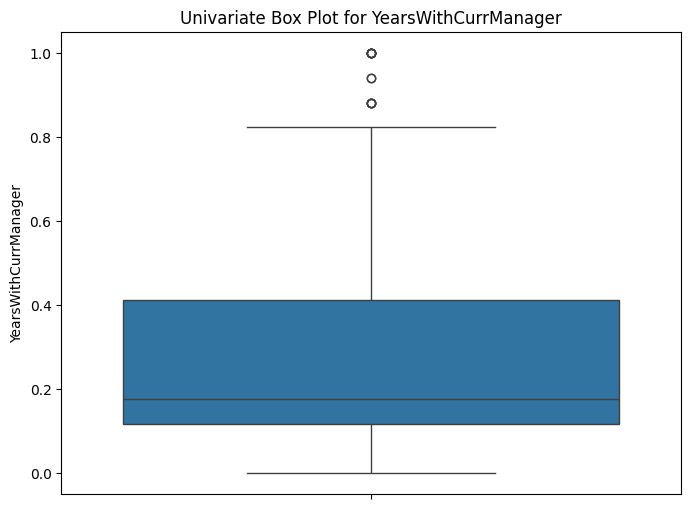

In [ ]:
# prompt: plot univarient quartile graph

for column in data.columns:
    # Check if the column is numerical before plotting
    if data[column].dtype in ['int64', 'float64']:
        # Check if the column has more than one unique value to avoid the ValueError
        if data[column].nunique() > 1:
            plt.figure(figsize=(8, 6))
            sns.boxplot(y=data[column])  # Use boxplot for quartile visualization
            plt.title(f'Univariate Box Plot for {column}')
            plt.ylabel(column)
            plt.show()
        else:
            print(f"Skipping box plot for '{column}' as it has only one unique value.")
    else:
        print(f"Skipping box plot for '{column}' as it is not numerical.")

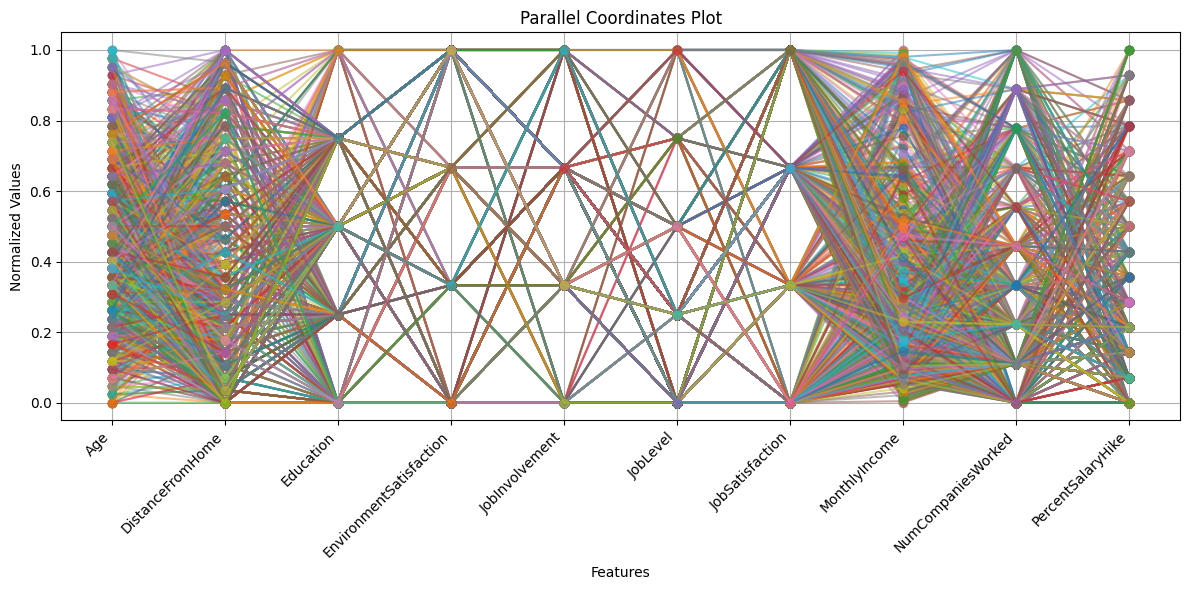

In [ ]:
!pip install pandas matplotlib scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Assuming your dataset is loaded into the 'data' DataFrame and X is defined

# Specify the columns you want to include in the parallel coordinates plot.
# Remove irrelevant columns here:
columns_for_parallel = [
    'Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
    'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
    'NumCompaniesWorked', 'PercentSalaryHike'
]

# Select the data for the parallel coordinates plot
subset_data = X[columns_for_parallel]

# Normalize the data to the range [0, 1] for better visualization
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(subset_data)
scaled_data = pd.DataFrame(scaled_data, columns=columns_for_parallel, index=subset_data.index)

# Create the parallel coordinates plot
plt.figure(figsize=(12, 6))

# Use a more efficient way to plot the lines
for _, row in scaled_data.iterrows():
    plt.plot(columns_for_parallel, row.values, marker='o', linestyle='-', alpha=0.5)

plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.title('Parallel Coordinates Plot')
plt.xlabel('Features')
plt.ylabel('Normalized Values')
plt.grid(True)
plt.tight_layout()  # Adjust layout to prevent overlapping elements
plt.show()